#Task 1

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn . linear_model import LinearRegression, Lasso , Ridge
from sklearn . metrics import mean_squared_error,r2_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set_theme ( style ="whitegrid")
print ("All libraries loaded successfully!")

df = pd.read_csv ("diamonds.csv")

print( f" Shape : {df. shape }")
df.head(5)

print(df.describe())



All libraries loaded successfully!
 Shape : (53940, 10)
              carat         depth         table             x             y  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184      5.731157      5.734526   
std        0.474011      1.432621      2.234491      1.121761      1.142135   
min        0.200000     43.000000     43.000000      0.000000      0.000000   
25%        0.400000     61.000000     56.000000      4.710000      4.720000   
50%        0.700000     61.800000     57.000000      5.700000      5.710000   
75%        1.040000     62.500000     59.000000      6.540000      6.540000   
max        5.010000     79.000000     95.000000     10.740000     58.900000   

                  z         price  
count  53940.000000  53940.000000  
mean       3.538734   3932.799722  
std        0.705699   3989.439738  
min        0.000000    326.000000  
25%        2.910000    950.000000  
50%        3.530

In [40]:
bad = df[(df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)]
print(f"\nRows with x=0, y=0, or z=0 (invalid): {len(bad)}")

df_clean = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)].copy()
print(f"\nRows before removal: {len(df)}")
print(f"Rows after removal: {len(df_clean)}")




Rows with x=0, y=0, or z=0 (invalid): 20

Rows before removal: 53940
Rows after removal: 53920


In [41]:
df_sample = df_clean.sample(n=5000, random_state=42).reset_index(drop=True)
print(f"Sample shape: {df_sample.shape}")
print(f"Price range in sample: ${df_sample['price'].min()} -- ${df_sample['price'].max()}")

Sample shape: (5000, 10)
Price range in sample: $335 -- $18823


In [42]:
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

enc = OrdinalEncoder(categories=[cut_order, color_order, clarity_order])

df_sample[['cut', 'color', 'clarity']] = enc.fit_transform(
    df_sample[['cut', 'color', 'clarity']]
)

print(df_sample[['cut', 'color', 'clarity']].head())

   cut  color  clarity
0  3.0    4.0      7.0
1  4.0    2.0      4.0
2  3.0    4.0      2.0
3  1.0    4.0      5.0
4  3.0    3.0      4.0


In [43]:
feature_cols = ['carat', 'cut', 'color', 'clarity',
                'depth', 'table', 'x', 'y', 'z']
target_col = 'price'

X_raw = df_sample[feature_cols].values.astype(float)
y = df_sample[target_col].values.astype(float)

print("Feature matrix shape:", X_raw.shape)
print("Target vector shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

Feature matrix shape: (5000, 9)
Target vector shape: (5000,)
Training samples: 4000
Test samples: 1000
Number of features: 9


In [44]:
scaler = StandardScaler()

# Fit on training data, transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data (do NOT fit again!)
X_test_scaled = scaler.transform(X_test)

print("Training feature means (should be ~0):")
print(X_train_scaled.mean(axis=0).round(4))

print("\nTraining feature stds (should be ~1):")
print(X_train_scaled.std(axis=0).round(4))

Training feature means (should be ~0):
[-0. -0.  0. -0. -0. -0.  0. -0.  0.]

Training feature stds (should be ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [45]:
def add_bias(X):
    """Prepend a column of ones to matrix X."""
    ones = np.ones((X.shape[0], 1))
    return np.hstack([ones, X])

X_train_b = add_bias(X_train_scaled)
X_test_b = add_bias(X_test_scaled)

print("Shape after adding bias column:", X_train_b.shape)
# (4000, 10) -- 9 features + 1 bias column

Shape after adding bias column: (4000, 10)


#Task 2

In [46]:
def predict_single(x, w):
  result = 0.0
  for j in range(len(x)):
    result += x[j] * w[j]
  return result

def predict(X, w):
  res_arr = []
  for x in X:
    res_arr.append(predict_single(x, w))
  return res_arr

In [47]:
n_features = X_train_b.shape[1]
w_init = np.zeros(n_features)
y_cap = predict(X_train_b, w_init)


In [48]:
def mse_loss(X,y,w):
  n = X.shape[0]
  total = 0.0
  for i in range(n):
    error = predict_single(X[i], w) - y[i]
    total += error * error
  return total / n


#Task 3

In [49]:
#3a
def compute_gradients(X, y , w):
  n = X.shape[0]
  n_weights = len(w)
  grads = []
  for i in range(n):
    error = predict_single(X[i], w) - y[i]
    for j in range(n_weights):
      grads.append(2/n * error * X[i][j])
  return grads


In [50]:
#3b
def gradient_descent_step(w, grads, lr):
  new_w = np.zeros(len(w))
  for j in range(len(w)):
    new_w[j] = w[j] - lr*grads[j]
  return new_w

Epoch   1 | Train MSE:  30262865.93 | Test MSE:  31151970.63
Epoch  50 | Train MSE:  30214757.84 | Test MSE:  31100690.69
Epoch 100 | Train MSE:  30167021.32 | Test MSE:  31049796.12
Epoch 150 | Train MSE:  30120609.70 | Test MSE:  31000303.71
Epoch 200 | Train MSE:  30075482.04 | Test MSE:  30952170.50
Epoch 250 | Train MSE:  30031598.79 | Test MSE:  30905354.99
Epoch 300 | Train MSE:  29988921.78 | Test MSE:  30859817.12


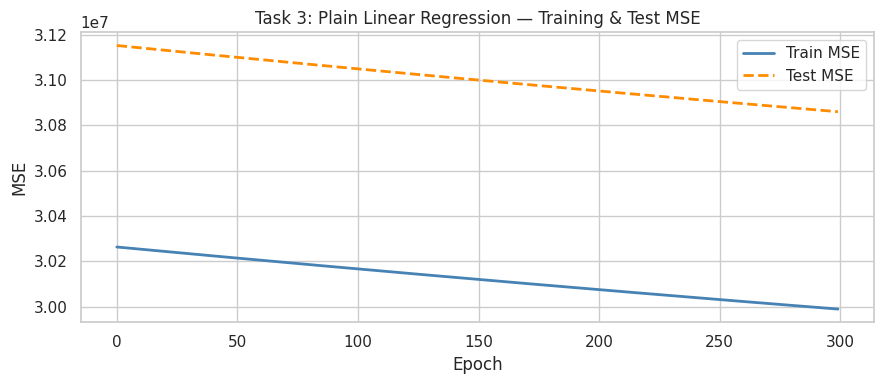


Final Train MSE (Plain): 29988921.78
Final Test  MSE (Plain): 30859817.12


In [51]:
#3c 3d
def train_model(X_train, y_train, X_test, y_test,
                epochs=300, lr=0.05,
                mode='plain', lam=0.0,
                print_every=50):

    w = np.zeros(X_train.shape[1])

    train_losses = []
    test_losses  = []

    for epoch in range(1, epochs + 1):

        if mode == 'l2':
            grads   = compute_gradients_l2(X_train, y_train, w, lam)
            tr_loss = mse_loss_l2(X_train, y_train, w, lam)
            te_loss = mse_loss_l2(X_test,  y_test,  w, lam)
        elif mode == 'l1':
            grads   = compute_gradients_l1(X_train, y_train, w, lam)
            tr_loss = mse_loss_l1(X_train, y_train, w, lam)
            te_loss = mse_loss_l1(X_test,  y_test,  w, lam)
        else:
            grads   = compute_gradients(X_train, y_train, w)
            tr_loss = mse_loss(X_train, y_train, w)
            te_loss = mse_loss(X_test,  y_test,  w)

        w = gradient_descent_step(w, grads, lr)

        train_losses.append(tr_loss)
        test_losses.append(te_loss)

        if epoch % print_every == 0 or epoch == 1:
            print(f"Epoch {epoch:3d} | Train MSE: {tr_loss:12.2f} | Test MSE: {te_loss:12.2f}")

    return w, train_losses, test_losses

w_plain, train_losses_plain, test_losses_plain = train_model(
    X_train_b, y_train, X_test_b, y_test,
    epochs=300, lr=0.05, mode='plain', print_every=50
)

plt.figure(figsize=(9, 4))
plt.plot(train_losses_plain, label='Train MSE', color='steelblue',   linewidth=2)
plt.plot(test_losses_plain,  label='Test MSE',  color='darkorange',  linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Task 3: Plain Linear Regression — Training & Test MSE')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nFinal Train MSE (Plain): {train_losses_plain[-1]:.2f}")
print(f"Final Test  MSE (Plain): {test_losses_plain[-1]:.2f}")


#Task 4

In [52]:
def mse_loss_l2(X, y, w, lam):
    n   = X.shape[0]
    mse = 0.0
    for i in range(n):
        error = predict_single(X[i], w) - y[i]
        mse  += error ** 2

    penalty = 0.0
    for j in range(1, len(w)):
        penalty += w[j] ** 2

    return mse / n + lam * penalty

In [53]:
def compute_gradients_l2(X, y, w, lam):
    n         = X.shape[0]
    n_weights = len(w)
    grads     = [0.0] * n_weights

    for i in range(n):
        error = predict_single(X[i], w) - y[i]
        for j in range(n_weights):
            grads[j] += (2 / n) * error * X[i][j]

    for j in range(1, n_weights):
        grads[j] += 2 * lam * w[j]

    return np.array(grads)

In [54]:
def sign(val):
    if val > 0:
        return 1.0
    elif val < 0:
        return -1.0
    else:
        return 0.0


def mse_loss_l1(X, y, w, lam):
    n   = X.shape[0]
    mse = 0.0
    for i in range(n):
        error = predict_single(X[i], w) - y[i]
        mse  += error ** 2

    penalty = 0.0
    for j in range(1, len(w)):
        penalty += abs(w[j])

    return mse / n + lam * penalty

In [55]:
def compute_gradients_l1(X, y, w, lam):
    n         = X.shape[0]
    n_weights = len(w)
    grads     = [0.0] * n_weights

    for i in range(n):
        error = predict_single(X[i], w) - y[i]
        for j in range(n_weights):
            grads[j] += (2 / n) * error * X[i][j]

    for j in range(1, n_weights):
        grads[j] += lam * sign(w[j])

    return np.array(grads)

In [56]:

print("\nTraining Ridge (L2)")
w_ridge, train_losses_ridge, test_losses_ridge = train_model(
    X_train_b, y_train, X_test_b, y_test,
    epochs=300, lr=0.05, mode='l2', lam=100, print_every=50
)


print("\nTraining Lasso (L1)")
w_lasso, train_losses_lasso, test_losses_lasso = train_model(
    X_train_b, y_train, X_test_b, y_test,
    epochs=300, lr=0.05, mode='l1', lam=100, print_every=50
)


print("\nFinal Test Comparison")
print(f"Plain Linear Regression : {test_losses_plain[-1]:>12.2f}")
print(f"Ridge (L2, lambda=100)  : {test_losses_ridge[-1]:>12.2f}")
#Ridge blew up ->  learning rate too high and the value of lambda is small too
print(f"Lasso (L1, lambda=100)  : {test_losses_lasso[-1]:>12.2f}")
#Smooth training, stable decrease

## Regularization shrinks the weights and usually reduces test MSE
##by preventing the model from over-fitting to the training data.


Training Ridge (L2)
Epoch   1 | Train MSE:  30262865.93 | Test MSE:  31151970.63
Epoch  50 | Train MSE: 133198507718917638035305544900916144812358523036006494404365420193004299464334935430951084496238149632.00 | Test MSE: 133259272018816908292980494771354655584514261681496096390116506812867470242622459868910329065637937152.00
Epoch 100 | Train MSE: 3456775947958068131185303667287648552539956047399535599582468121879155293565326894591763265530500988237690053492777209846212463851789860849446903601534997308271943557356273068283398308724102441992192.00 | Test MSE: 3458308816399941194123330136371925983543829465923751205719106357618059800821570383773804381797872993720529576446304419039531008733346248757924953101634066664481112741771597653096249930150489842778112.00
Epoch 150 | Train MSE: 898327274963960848604717321580086213202477909328532770748662249218917509488604423488929260731604418904146689252832336090437968524956836072947979618578449663527543457649143121372993623109244839000971007225523

/tmp/ipykernel_1139/4121282992.py:6: RuntimeWarning: overflow encountered in scalar add
  mse  += error ** 2
/tmp/ipykernel_1139/4121282992.py:6: RuntimeWarning: overflow encountered in scalar power
  mse  += error ** 2
/tmp/ipykernel_1139/4121282992.py:12: RuntimeWarning: overflow encountered in scalar multiply
  return mse / n + lam * penalty
/tmp/ipykernel_1139/4121282992.py:10: RuntimeWarning: overflow encountered in scalar power
  penalty += w[j] ** 2


Epoch 200 | Train MSE:          inf | Test MSE:          inf
Epoch 250 | Train MSE:          inf | Test MSE:          inf
Epoch 300 | Train MSE:          inf | Test MSE:          inf

Training Lasso (L1)
Epoch   1 | Train MSE:  30262865.93 | Test MSE:  31151970.63
Epoch  50 | Train MSE:   2359409.13 | Test MSE:   2298074.55
Epoch 100 | Train MSE:   2174300.97 | Test MSE:   2151669.35
Epoch 150 | Train MSE:   2070696.92 | Test MSE:   2059886.58
Epoch 200 | Train MSE:   2001359.80 | Test MSE:   1997432.30
Epoch 250 | Train MSE:   1947166.49 | Test MSE:   1950534.77
Epoch 300 | Train MSE:   1905213.22 | Test MSE:   1915534.81

Final Test Comparison
Plain Linear Regression :  30859817.12
Ridge (L2, lambda=100)  :          inf
Lasso (L1, lambda=100)  :   1915534.81


#Task 5

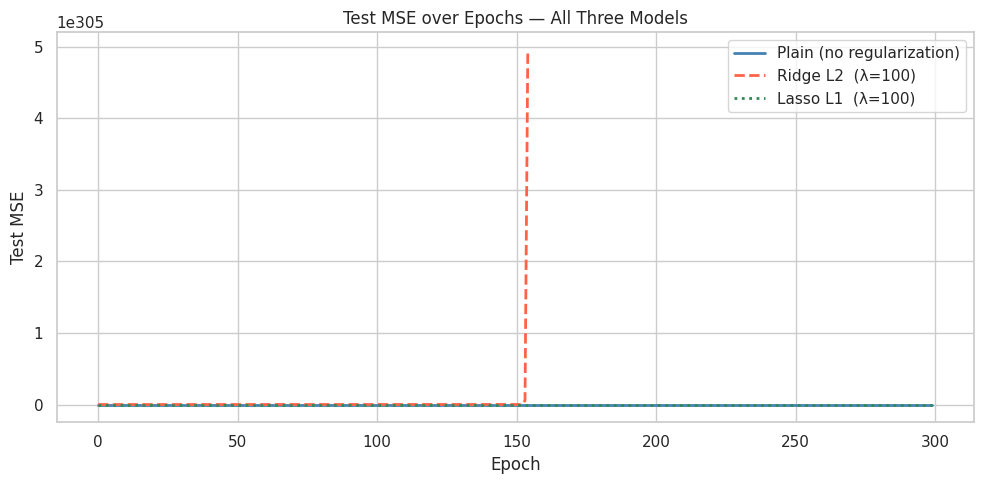

In [57]:
plt.figure(figsize=(10, 5))
plt.plot(test_losses_plain, label='Plain (no regularization)', color='steelblue',  linewidth=2)
plt.plot(test_losses_ridge, label='Ridge L2  (λ=100)',         color='tomato',     linewidth=2, linestyle='--')
plt.plot(test_losses_lasso, label='Lasso L1  (λ=100)',         color='seagreen',   linewidth=2, linestyle=':')
plt.xlabel('Epoch')
plt.ylabel('Test MSE')
plt.title('Test MSE over Epochs — All Three Models')
plt.legend()
plt.tight_layout()
plt.show()

In [58]:
lambdas = [1, 10, 100, 500, 1000, 5000]
final_test_mse_by_lam = []


print(f"{'Lambda':>8} | Final Test MSE")
print("-" * 30)

for lam in lambdas:
    _, _, t_losses = train_model(
        X_train_b, y_train, X_test_b, y_test,
        epochs=300, lr=0.05, mode='l2', lam=lam,
        print_every=9999
    )
    final_mse = t_losses[-1]
    final_test_mse_by_lam.append(final_mse)
    print(f"{lam:>8} | {final_mse:.2f}")

best_lam     = lambdas[np.argmin(final_test_mse_by_lam)]
best_mse     = min(final_test_mse_by_lam)
print(f"\nBest lambda = {best_lam}  →  Final Test MSE = {best_mse:.2f}")

  Lambda | Final Test MSE
------------------------------
Epoch   1 | Train MSE:  30262865.93 | Test MSE:  31151970.63
       1 | 5265680.41
Epoch   1 | Train MSE:  30262865.93 | Test MSE:  31151970.63
      10 | 12011185.64
Epoch   1 | Train MSE:  30262865.93 | Test MSE:  31151970.63


/tmp/ipykernel_1139/4121282992.py:6: RuntimeWarning: overflow encountered in scalar add
  mse  += error ** 2
/tmp/ipykernel_1139/4121282992.py:6: RuntimeWarning: overflow encountered in scalar power
  mse  += error ** 2
/tmp/ipykernel_1139/4121282992.py:12: RuntimeWarning: overflow encountered in scalar multiply
  return mse / n + lam * penalty
/tmp/ipykernel_1139/4121282992.py:10: RuntimeWarning: overflow encountered in scalar power
  penalty += w[j] ** 2


     100 | inf
Epoch   1 | Train MSE:  30262865.93 | Test MSE:  31151970.63


/tmp/ipykernel_1139/2210266437.py:9: RuntimeWarning: invalid value encountered in scalar add
  grads[j] += (2 / n) * error * X[i][j]
/tmp/ipykernel_1139/1117599308.py:4: RuntimeWarning: invalid value encountered in scalar add
  result += x[j] * w[j]


     500 | nan
Epoch   1 | Train MSE:  30262865.93 | Test MSE:  31151970.63
    1000 | nan
Epoch   1 | Train MSE:  30262865.93 | Test MSE:  31151970.63
    5000 | nan

Best lambda = 500  →  Final Test MSE = 5265680.41


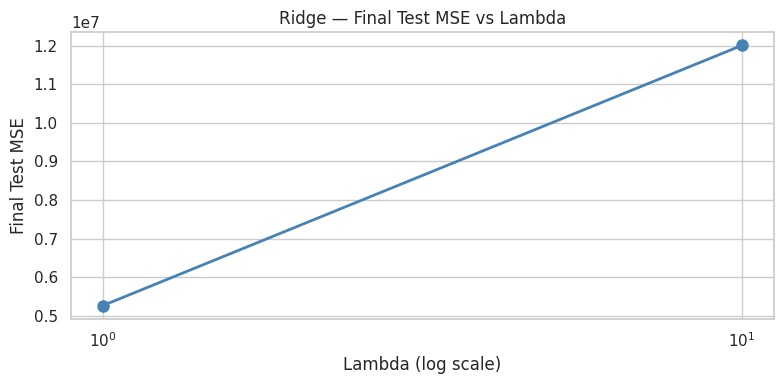

In [59]:
plt.figure(figsize=(8, 4))
plt.plot(lambdas, final_test_mse_by_lam,
         marker='o', color='steelblue', linewidth=2, markersize=8)
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Final Test MSE')
plt.title('Ridge — Final Test MSE vs Lambda')
plt.tight_layout()
plt.show()

In [60]:
"""

Q1: What happens to the weights as lambda increases?
    As lambda grows larger, the regularisation penalty penalises
    big weights more and more heavily.  Gradient descent therefore
    keeps shrinking the feature weights (w1 … w9) toward zero.
    The bias term w0 is not penalised, so it stays the same.

Q2: Is there a sweet spot for lambda?
    Yes.  Too small then model over-fits the training data
    Too large  then model under-fits: all weights collapse toward 0,
    making predictions nearly constant.
    The sweet spot balances these two extremes.

Q3: What does a very large lambda do?
    With lambda = 5000 all feature weights are driven very close to
    zero.  The model predicts roughly the same value (near the mean
    price) for every diamond regardless of its properties, so both
    training and test MSE rise sharply.(Underfitting)
"""

'\n \nQ1: What happens to the weights as lambda increases?\n    As lambda grows larger, the regularisation penalty penalises\n    big weights more and more heavily.  Gradient descent therefore\n    keeps shrinking the feature weights (w1 … w9) toward zero.\n    The bias term w0 is not penalised, so it stays the same.\n \nQ2: Is there a sweet spot for lambda?\n    Yes.  Too small then model over-fits the training data\n    Too large  then model under-fits: all weights collapse toward 0,\n    making predictions nearly constant.\n    The sweet spot balances these two extremes.\n \nQ3: What does a very large lambda do?\n    With lambda = 5000 all feature weights are driven very close to\n    zero.  The model predicts roughly the same value (near the mean\n    price) for every diamond regardless of its properties, so both\n    training and test MSE rise sharply.(Underfitting)\n'

#Task 6

In [61]:
sk_lr    = LinearRegression()
sk_ridge = Ridge(alpha=100)
sk_lasso = Lasso(alpha=100, max_iter=10000)

sk_lr.fit(X_train_scaled,    y_train)
sk_ridge.fit(X_train_scaled, y_train)
sk_lasso.fit(X_train_scaled, y_train)

sk_mse_lr    = mean_squared_error(y_test, sk_lr.predict(X_test_scaled))
sk_mse_ridge = mean_squared_error(y_test, sk_ridge.predict(X_test_scaled))
sk_mse_lasso = mean_squared_error(y_test, sk_lasso.predict(X_test_scaled))

our_mse_plain = test_losses_plain[-1]
our_mse_ridge = test_losses_ridge[-1]
our_mse_lasso = test_losses_lasso[-1]

print("\nTest MSE Comparison")
print(f"{'Method':<25} {'Our Impl (MSE)':>16} {'sklearn (MSE)':>16}")
print("-" * 60)
print(f"{'Plain Linear Regression':<25} {our_mse_plain:>16.2f} {sk_mse_lr:>16.2f}")
print(f"{'Ridge (lambda=100)':<25} {our_mse_ridge:>16.2f} {sk_mse_ridge:>16.2f}")
print(f"{'Lasso (lambda=100)':<25} {our_mse_lasso:>16.2f} {sk_mse_lasso:>16.2f}")


print("\nFeature Weight Comparison: Plain LR vs sklearn LinearRegression")
print(f"{'Feature':<14} {'Our Weight':>12} {'sklearn Wt':>12} {'Difference':>12}")
print("-" * 54)
our_body = w_plain[1:]
sk_body  = sk_lr.coef_

for i, name in enumerate(feature_cols):
    diff = our_body[i] - sk_body[i]
    print(f"{name:<14} {our_body[i]:>12.2f} {sk_body[i]:>12.2f} {diff:>12.2f}")

print(f"\n{'Intercept':<14} {w_plain[0]:>12.2f} {sk_lr.intercept_:>12.2f}")


Test MSE Comparison
Method                      Our Impl (MSE)    sklearn (MSE)
------------------------------------------------------------
Plain Linear Regression        30859817.12       1299954.04
Ridge (lambda=100)                     inf       1392992.46
Lasso (lambda=100)              1915534.81       1396856.98

Feature Weight Comparison: Plain LR vs sklearn LinearRegression
Feature          Our Weight   sklearn Wt   Difference
------------------------------------------------------
carat                  0.93      5613.60     -5612.66
cut                  -23.91       113.59      -137.50
color                -28.97       513.41      -542.38
clarity               -9.05       791.54      -800.59
depth                -42.96       -31.15       -11.81
table                  9.22       -88.20        97.43
x                      6.13      -491.35       497.48
y                      6.40       197.88      -191.48
z                      0.85     -1236.32      1237.17

Intercept        

In [62]:
"""
sklearn LinearRegression solves the problem analytically using the
Normal Equation:
        w* = (X^T X)^-1  X^T y
This finds the mathematically exact minimum-MSE weights in one shot.

Our gradient descent only runs for 300 epochs, which may not yet
be fully converged (especially for features with large gradients).

How to close the gap:
  1. Train for more epochs (e.g., 1000 or 2000).
  2. Reduce the learning rate gradually over time (learning rate decay).
  3. Add a convergence check: stop when the gradient magnitude
     falls below a tiny threshold.

"""

'\nsklearn LinearRegression solves the problem analytically using the\nNormal Equation:\n        w* = (X^T X)^-1  X^T y\nThis finds the mathematically exact minimum-MSE weights in one shot.\n \nOur gradient descent only runs for 300 epochs, which may not yet\nbe fully converged (especially for features with large gradients).\n \nHow to close the gap:\n  1. Train for more epochs (e.g., 1000 or 2000).\n  2. Reduce the learning rate gradually over time (learning rate decay).\n  3. Add a convergence check: stop when the gradient magnitude\n     falls below a tiny threshold.\n\n'